In [18]:
from matplotlib.image import imread
import matplotlib.pyplot as plt
import numpy as np
import os
plt.rcParams['figure.figsize'] = [16,8]

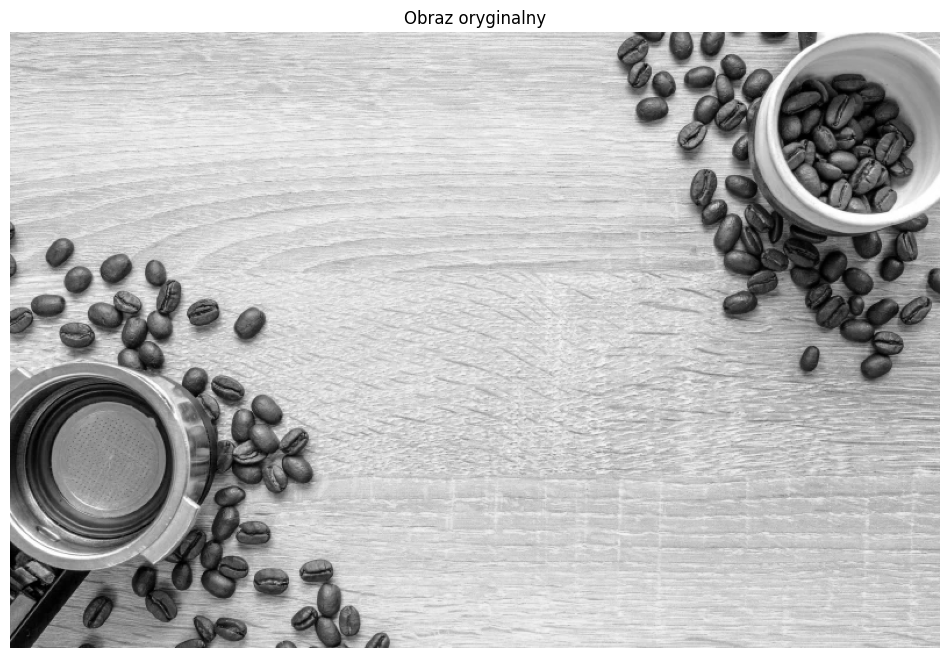

In [19]:
A = imread('12.webp')
X = np.mean(A,-1)

img = plt.imshow(X)
img.set_cmap('gray')
plt.axis('off')
plt.title('Obraz oryginalny')
plt.show()

In [20]:
U, S, VT = np.linalg.svd(X, full_matrices=False)

print(S.shape)

cum_sum = np.cumsum(S) / np.sum(S)
k90 = np.argmax(cum_sum >= 0.90) + 1

print("Liczba wartości singularnych potrzebna do zachowania 90% informacji:", k90)

S = np.diag(S)

(530,)
Liczba wartości singularnych potrzebna do zachowania 90% informacji: 227


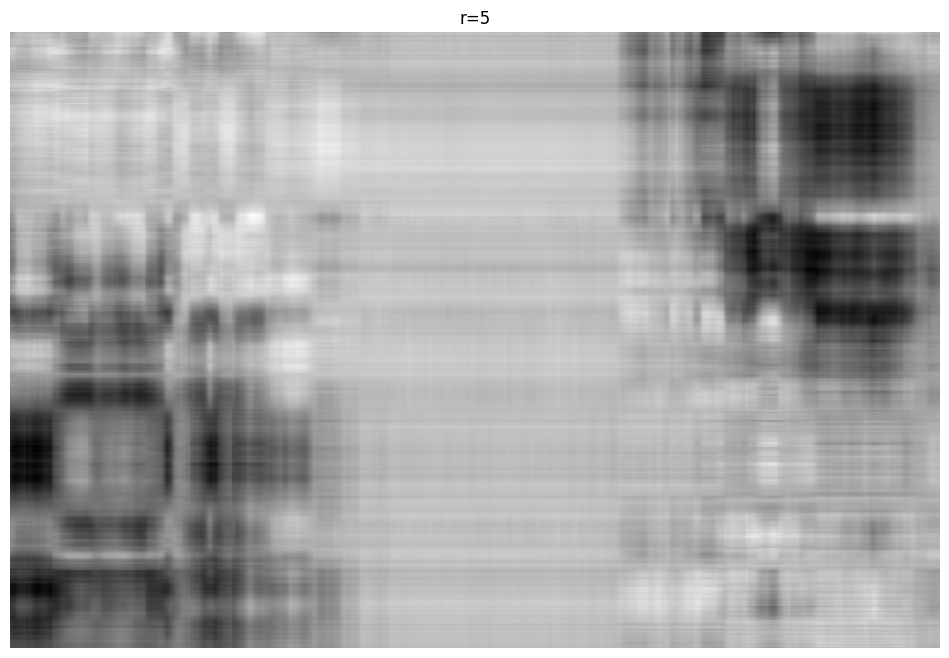

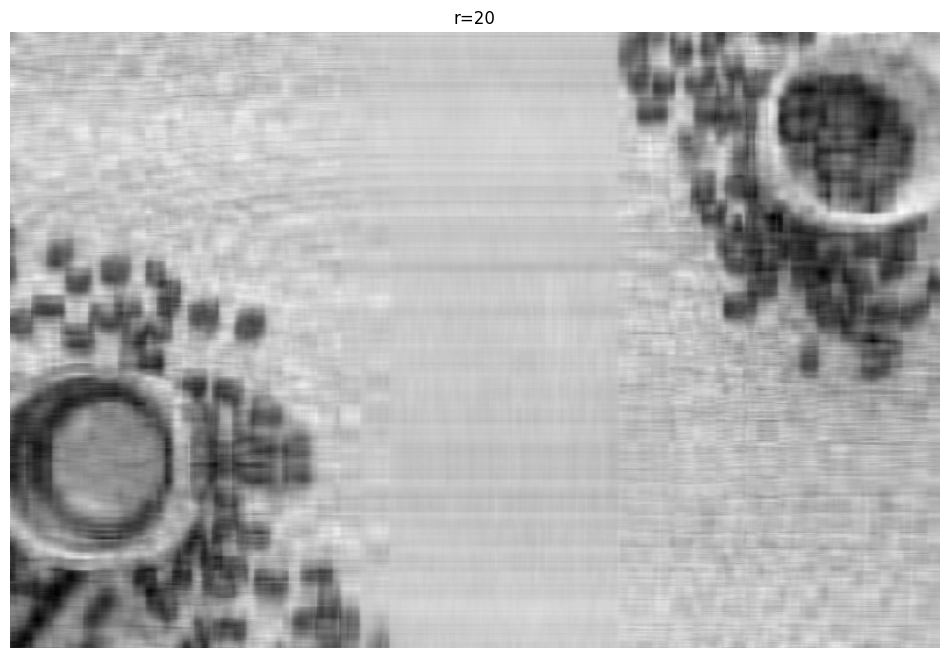

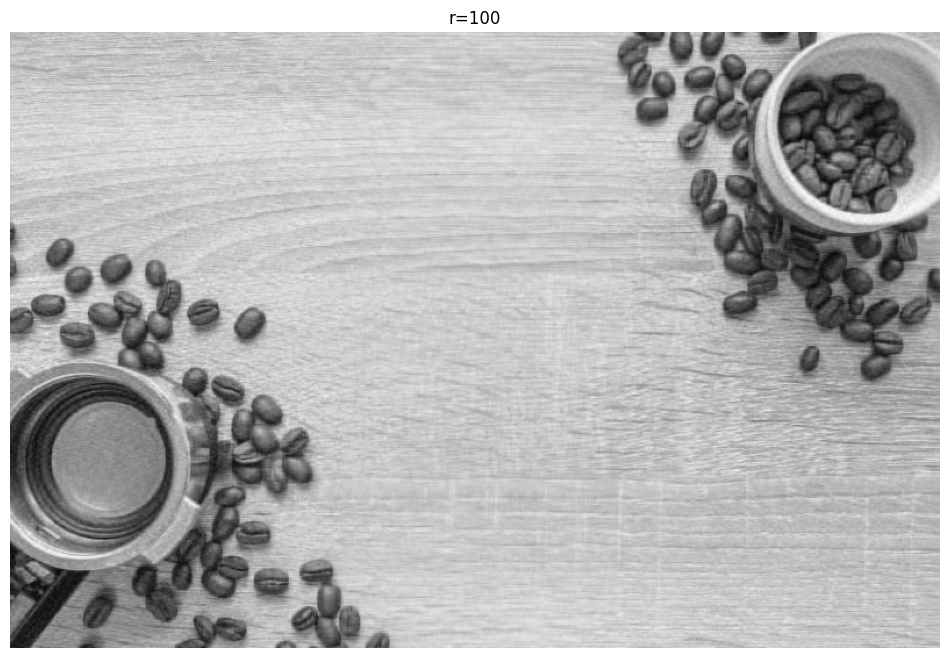

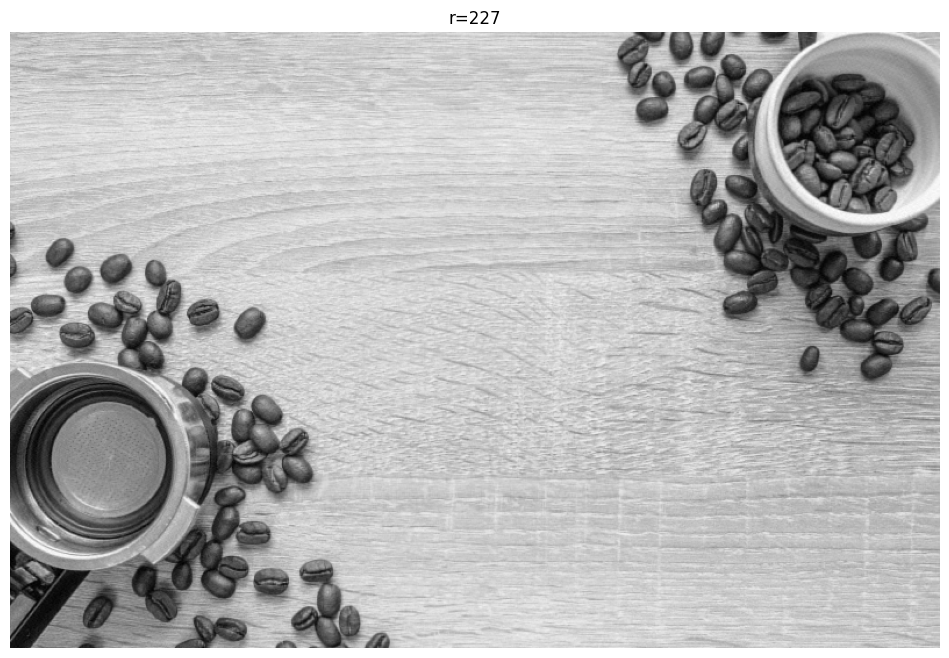

In [21]:
j = 0
for r in (5, 20, 100, 227):
    Xapprox = U[:, :r] @ S[0:r, :r] @ VT[:r, :]
    plt.figure(j+1)
    j += 1
    img = plt.imshow(Xapprox)
    img.set_cmap('gray')
    plt.axis('off')
    plt.title('r=' + str(r))
    plt.show()

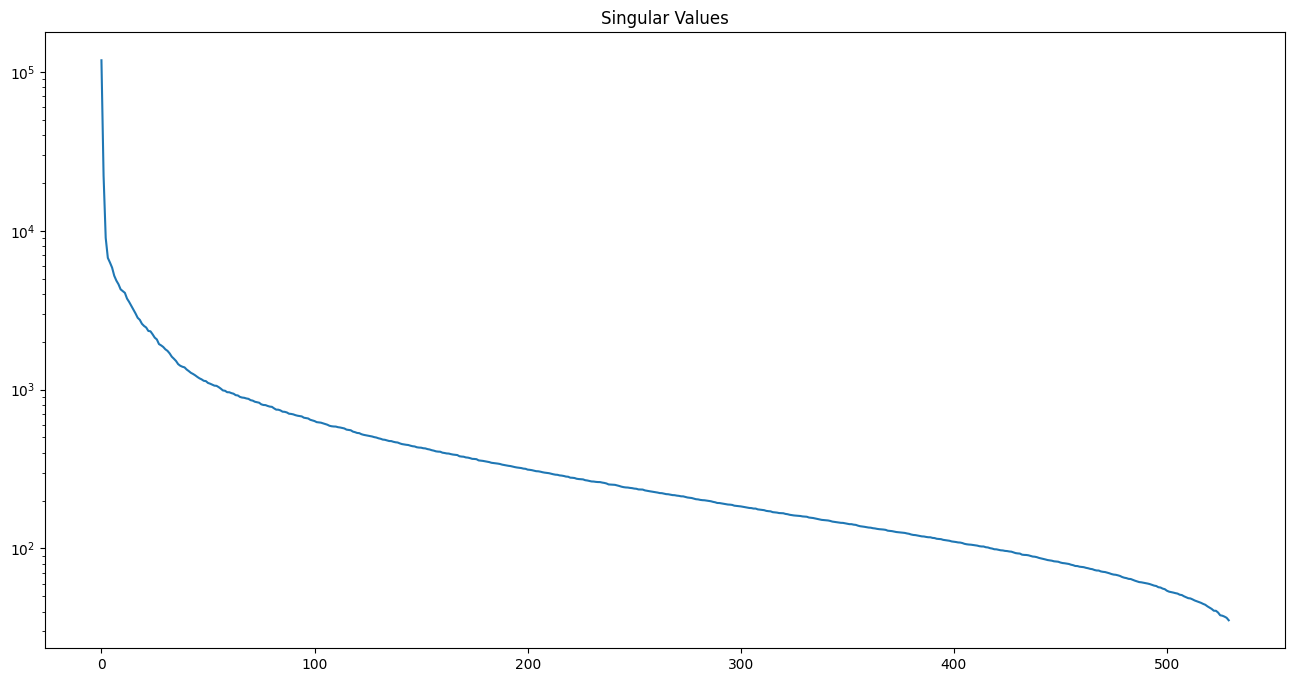

In [22]:
plt.figure(1)
plt.semilogy(np.diag(S))
plt.title('Singular Values')
plt.show()

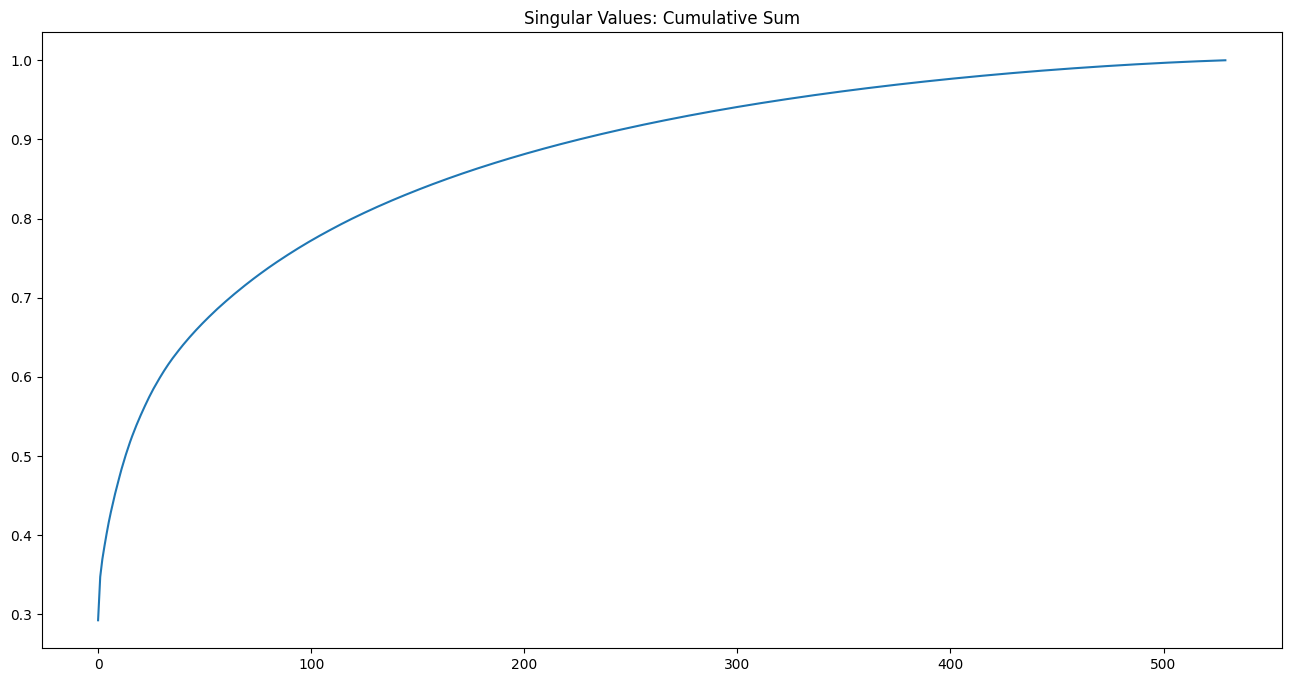

In [23]:
plt.figure(2)
plt.plot(np.cumsum(np.diag(S))/np.sum(np.diag(S)))
plt.title('Singular Values: Cumulative Sum')
plt.show()

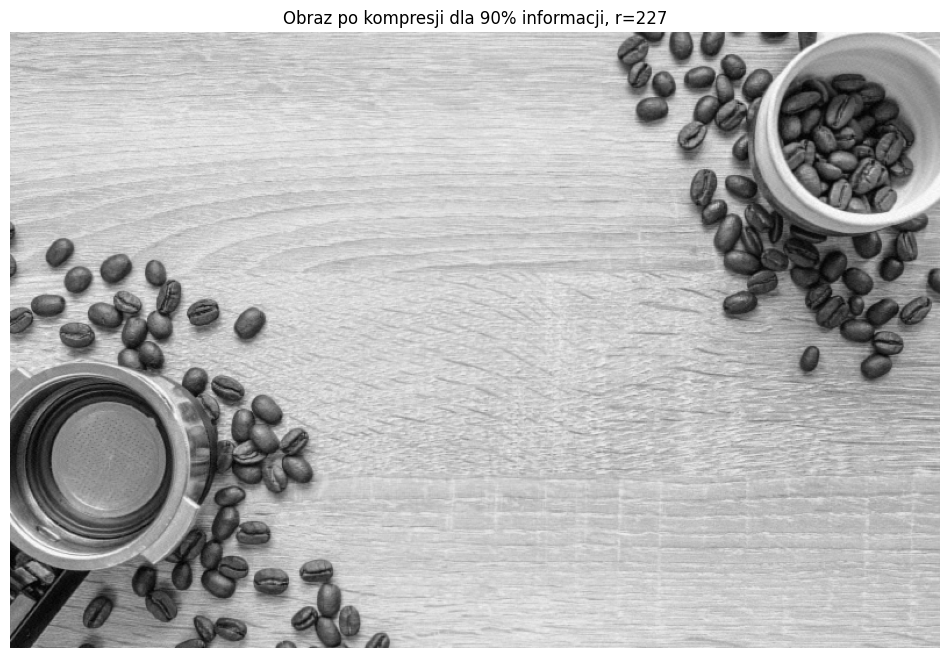

In [24]:
Xapprox_90 = U[:, :k90] @ S[0:k90, 0:k90] @ VT[:k90, :]

img = plt.imshow(Xapprox_90)
img.set_cmap('gray')
plt.axis('off')
plt.title('Obraz po kompresji dla 90% informacji, r=' + str(k90))
plt.show()